In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Ridge

from hkan_original import (
    Sigmoid, Gaussian, ReLU, Softplus, Tanh, Identity,
    make_hkan_layer, extend_hkan,
    set_tqdm_disable
)
from datasets import load_dataset

In [2]:
data = load_dataset("TF5")
X_train, X_test, y_train, y_test = data["train_input"], data["test_input"], data["train_label"], data["test_label"]

model = make_hkan_layer(
    layer_idx=0,
    n_vars_out=912,
    basis_fn=Tanh(s=50),
    n_basis=23,
    centers="random",
    expanding_base_regressor=Ridge(alpha=0.01),
)

model = extend_hkan(
    model,
    layer_idx=1,
    n_vars_out=1,
    basis_fn=Identity(),
    centers="random_data_points",
    expanding_base_regressor=Ridge(alpha=0.1),
)

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('expanding_layer_0', ...), ('connecting_layer_0', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_vars_out,912
,n_basis,23
,centers,'random'
,basis_fn,<hkan_origina...t 0x16b028690>
,base_regressor,Ridge(alpha=0.01)
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True


In [3]:
set_tqdm_disable(False)

In [4]:
model.fit(X_train, y_train);

Fitting 1D regressors:   0%|          | 0/1824 [00:00<?, ?it/s]

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  1.04it/s]


In [5]:
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse:g}")

RMSE: 5.02084e-13


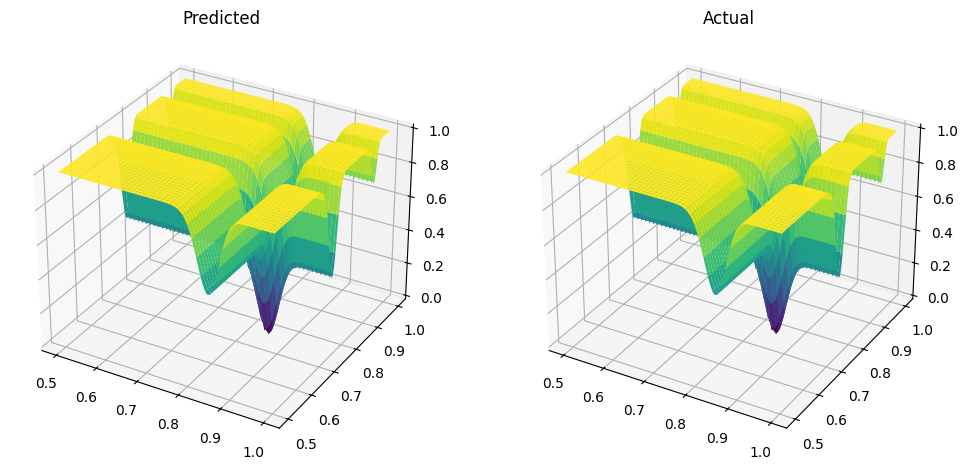

In [6]:
fig = plt.figure(figsize=(12, 6))
X1, X2 = X_test[:, 0].reshape(100, 100), X_test[:, 1].reshape(100, 100)
ax = fig.add_subplot(121, projection="3d")
ax.plot_surface(X1, X2, y_pred.reshape(100, 100), cmap="viridis")
ax.set_title("Predicted")
ax = fig.add_subplot(122, projection="3d")
ax.plot_surface(X1, X2, y_test.reshape(100, 100), cmap="viridis")
ax.set_title("Actual");